# `quickview`: a diagnostics dashboard in one call

`Timeseries.quickview()` computes and lays out a standard panel set, which is usually
the first thing you want when looking at a new run.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
case = x4c.Timeseries(case_dir, grid_dict={'atm': 'ne16np4', 'ocn': 'g16'},
                      cesm_ver=1)

>>> case.root_dir: /glade/u/home/fengzhu/.cache/x4c/sample_data/cesm1_sample_data/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.path_pattern: comp/proc/tseries/*/casename.hstr.vn.timespan.nc
>>> case.grid_dict: {'atm': 'ne16np4', 'ocn': 'g16', 'lnd': 'ne16np4', 'rof': 'ne16np4', 'ice': 'g16'}
>>> case.casename: b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.paths["atm"]["cam.h0"] created
>>> case.paths["ocn"]["pop.h"] created
>>> case.paths["lnd"]["clm2.h0"] created
>>> case.paths["ice"]["cice.h"] created
>>> case.vns["atm"]["cam.h0"] created
>>> case.vns["ocn"]["pop.h"] created
>>> case.vns["lnd"]["clm2.h0"] created
>>> case.vns["ice"]["cice.h"] created


## The default panel set

With no arguments beyond a timespan, `quickview` computes eight standard diagnostics:
global-mean surface temperature, net radiative flux at the top of atmosphere, the
longwave and shortwave cloud forcings, NH sea-ice area and its annual cycle, the
Southern Ocean overturning minimum, and the meridional overturning streamfunction.

Each panel is a spell, so nothing here is special-cased — it is the same machinery as
`case.calc()`.

>>> Plotting 8 subplots
>>> nrow = 2, ncol = np.int64(4)
>>> Spell `TS:ann:gm` is already calculated and the calculation is skipped.
>>> Spell `RESTOM:ann:gm` is already calculated and the calculation is skipped.
>>> Spell `LWCF:ann:gm` is already calculated and the calculation is skipped.
>>> Spell `SWCF:ann:gm` is already calculated and the calculation is skipped.
>>> Spell `ICEFRAC:ann:nhs` is already calculated and the calculation is skipped.
>>> Spell `ICEFRAC:climo:nhs` is already calculated and the calculation is skipped.
>>> Spell `MOC:ann:somin` is already calculated and the calculation is skipped.
>>> Spell `MOC:ann:yz` is already calculated and the calculation is skipped.
>>> Plotting GMST
>>> Plotting GMRESTOM
>>> Plotting GMLWCF
>>> Plotting GMSWCF
>>> Plotting NHICEFRAC
>>> Plotting NHICEFRAC_clim
>>> Plotting SOMOC
>>> Plotting MOC


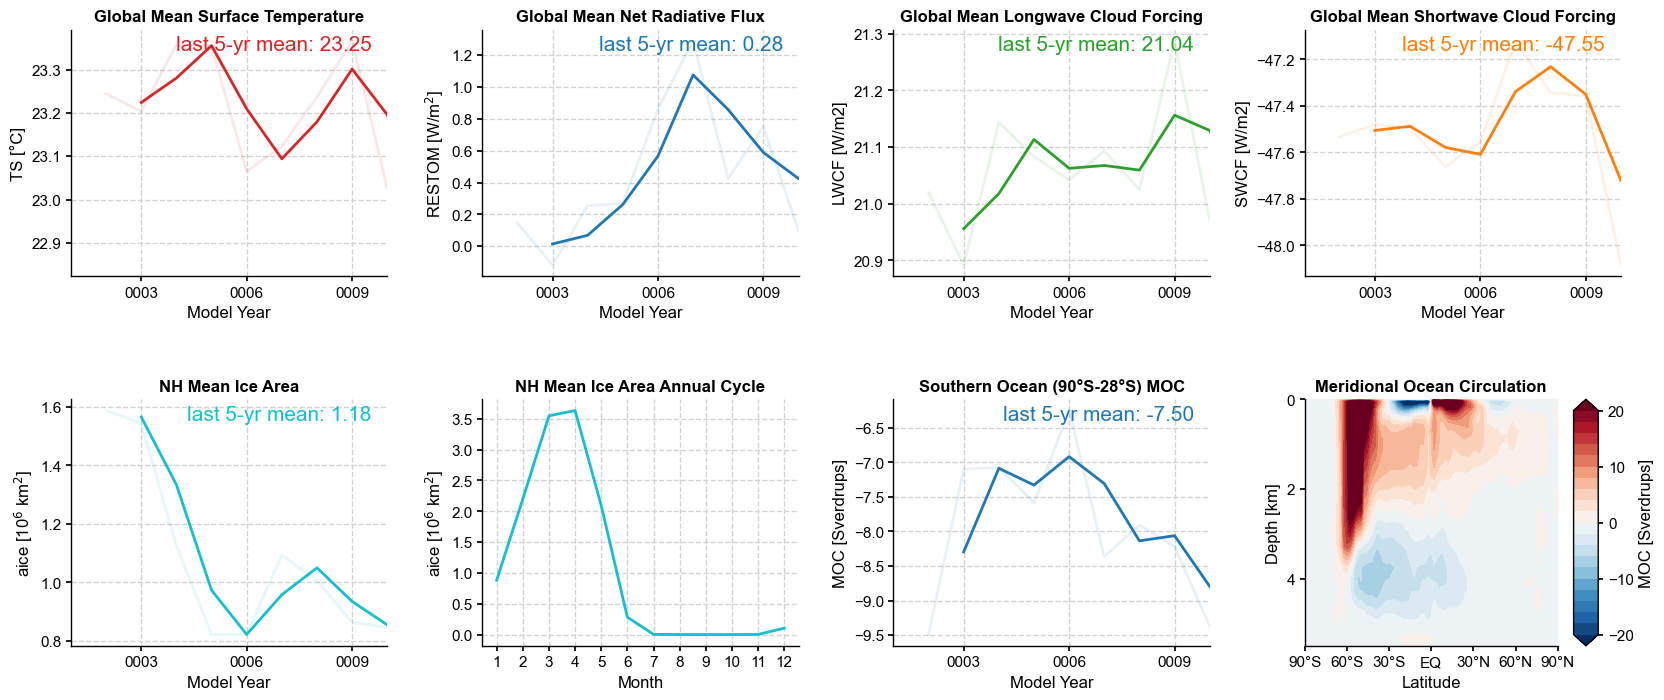

In [9]:
fig, ax = case.quickview(timespan=(1, 10), roll_int=2, stat_period=-5)
x4c.showfig(fig)

`ax` is a dict keyed by panel name, so anything matplotlib can do to an axis is
available afterwards.

In [4]:
print('panels:', list(ax))

panels: ['GMST', 'GMRESTOM', 'GMLWCF', 'GMSWCF', 'NHICEFRAC', 'NHICEFRAC_clim', 'SOMOC', 'MOC']


## `somin`: the Southern Ocean overturning minimum

The `SOMOC` panel uses `.x.somin`, which takes the minimum of a latitude-by-depth field
over 90S-28S. It is a common single-number summary of Southern Ocean ventilation.

In [5]:
somoc = case.calc('MOC:ann:somin', timespan=(1, 10), verbose=False)
print('Southern Ocean MOC minimum (Sv):')
print(np.round(somoc.values, 3))

>>> Spell `MOC:ann:somin` is already calculated and the calculation is skipped.
Southern Ocean MOC minimum (Sv):
[-9.493 -7.098 -7.073 -7.584 -6.249 -8.366 -7.906 -8.218 -9.373 -9.421]


## A custom panel set

Pass your own `spells` dict to replace the defaults. The layout is derived from the
keys, so you do not have to supply `ax_loc` as well.

>>> Plotting 4 subplots
>>> nrow = 1, ncol = np.int64(4)
>>> Spell `TS:ann:gm` is already calculated and the calculation is skipped.
>>> Spell `PRECT:ann:gm` is already calculated and the calculation is skipped.
>>> Spell `RESTOM:ann:gm` is already calculated and the calculation is skipped.
>>> Spell `d18Op:ann:gm` is already calculated and the calculation is skipped.
>>> Plotting GMST
>>> Plotting PRECIP
>>> Plotting RESTOM
>>> Plotting d18Op


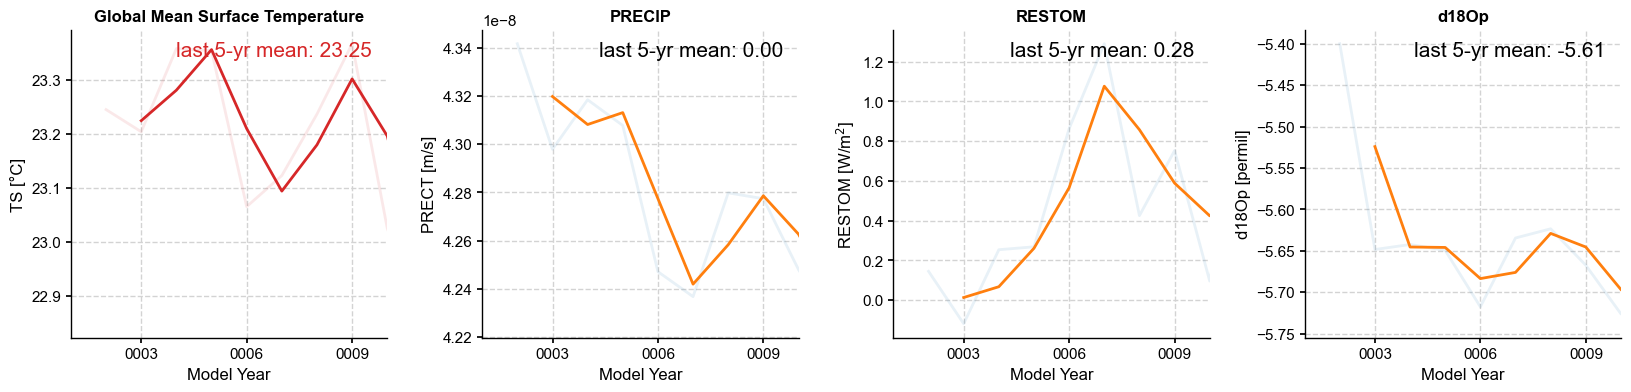

In [8]:
spells = {
    'GMST':    'TS:ann:gm',
    'PRECIP':  'PRECT:ann:gm',
    'RESTOM':  'RESTOM:ann:gm',
    'd18Op':   'd18Op:ann:gm',
}
fig, ax = case.quickview(spells=spells, timespan=(1, 10), roll_int=2, stat_period=-5)
x4c.showfig(fig)

`roll_int` sets the width of the smoothing line drawn over each timeseries. It is
clamped to the length of the record, so a short run does not fail — the default (50
years) is longer than this ten-year sample.

`stat_period` is not clamped: it is the negative time index passed straight to
`isel(time=slice(stat_period,))`, and the panel label always reads `last
{abs(stat_period)}-yr mean`. On a record shorter than 50 years the default still
"works" (the slice just returns everything available), but the label would claim a
50-year mean over a 10-year sample, so both calls above pass `stat_period=-10` to keep
the label honest.

## Colormap inference

When you do not name a colormap, `x4c` picks one from the variable's `long_name`. That
is why a temperature map comes out diverging and a precipitation map comes out
`BrBG` without being told.

In [7]:
from x4c.visual import infer_cmap

for long_name in ['Surface Temperature', 'Total precipitation rate',
                  'Sea Surface Salinity', 'Meridional Ocean Circulation',
                  'Mixed Layer Depth', 'something unrecognised']:
    da = xr.DataArray([0.0])
    da.attrs['long_name'] = long_name
    print(f'  {long_name:32s} -> {infer_cmap(da)}')

  Surface Temperature              -> RdBu_r
  Total precipitation rate         -> BrBG
  Sea Surface Salinity             -> PiYG
  Meridional Ocean Circulation     -> RdBu_r
  Mixed Layer Depth                -> GnBu
  something unrecognised           -> viridis
